# Refinement Process Metrics Analysis

This notebook analyzes the feedback refinement process from the MRBench v3 testset.


In [1]:
# Import required libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the refinement data
data = []
with open('outputs/mrbench_v3_testset_refinements.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

print(f"Total conversations loaded: {len(data)}")

Total conversations loaded: 1547


## 1. Iteration Statistics


In [3]:
# Calculate iteration statistics
iteration_counts = [len(conv['iterations']) for conv in data]
completed_status = [conv['completed'] for conv in data]

# Create summary dataframe
iteration_stats = pd.DataFrame({
    'num_iterations': iteration_counts,
    'completed': completed_status
})

# Overall statistics
print("=" * 60)
print("ITERATION STATISTICS")
print("=" * 60)
print(f"\nTotal conversations: {len(data)}")
print(f"Completed refinements: {sum(completed_status)} ({sum(completed_status)/len(data)*100:.1f}%)")
print(f"Not completed: {len(data) - sum(completed_status)} ({(len(data) - sum(completed_status))/len(data)*100:.1f}%)")
print(f"\nAverage iterations: {np.mean(iteration_counts):.2f}")
print(f"Median iterations: {np.median(iteration_counts):.0f}")
print(f"Min iterations: {np.min(iteration_counts)}")
print(f"Max iterations: {np.max(iteration_counts)}")
print(f"Std deviation: {np.std(iteration_counts):.2f}")

# Iteration distribution
print(f"\nIteration distribution:")
iter_dist = Counter(iteration_counts)
for num_iter in sorted(iter_dist.keys()):
    count = iter_dist[num_iter]
    print(f"  {num_iter} iteration(s): {count} conversations ({count/len(data)*100:.1f}%)")

ITERATION STATISTICS

Total conversations: 1547
Completed refinements: 1369 (88.5%)
Not completed: 178 (11.5%)

Average iterations: 1.87
Median iterations: 2
Min iterations: 1
Max iterations: 3
Std deviation: 0.74

Iteration distribution:
  1 iteration(s): 537 conversations (34.7%)
  2 iteration(s): 676 conversations (43.7%)
  3 iteration(s): 334 conversations (21.6%)


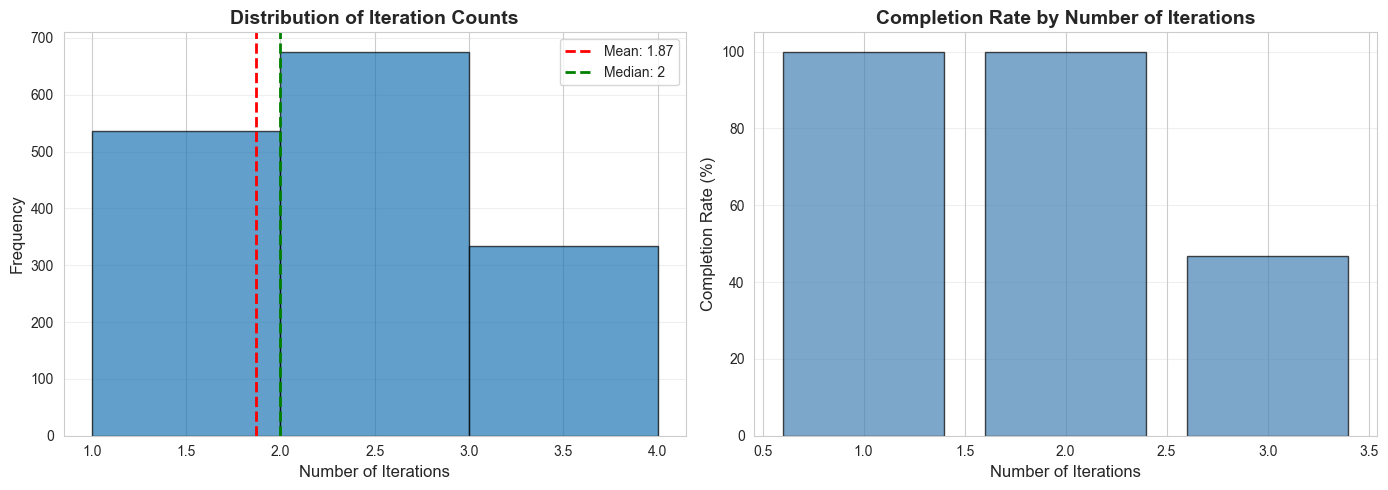

In [4]:
# Visualization: Iteration distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(iteration_counts, bins=range(1, max(iteration_counts)+2), edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(iteration_counts), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(iteration_counts):.2f}')
axes[0].axvline(np.median(iteration_counts), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(iteration_counts):.0f}')
axes[0].set_xlabel('Number of Iterations', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Iteration Counts', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Completion status by iterations
completed_by_iter = iteration_stats.groupby('num_iterations')['completed'].agg(['sum', 'count'])
completed_by_iter['completion_rate'] = (completed_by_iter['sum'] / completed_by_iter['count'] * 100)
completed_by_iter.reset_index(inplace=True)

axes[1].bar(completed_by_iter['num_iterations'], completed_by_iter['completion_rate'], 
            edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Number of Iterations', fontsize=12)
axes[1].set_ylabel('Completion Rate (%)', fontsize=12)
axes[1].set_title('Completion Rate by Number of Iterations', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Predicted Labels Analysis


In [5]:
# Extract predicted labels from BD predictions (final iteration)
bd_tasks = ['Mistake Identification (includes the relevant mistake identification)',
            'Mistake Location (points to the mistake\'s location in the answer and outline what the error is to help the student remediate)',
            'Actionability (provides what the student should do next)']

final_predictions = {task: [] for task in bd_tasks}
final_predictions['Providing Guidance (should provide the student with relevant and helpful guidance)'] = []

for conv in data:
    final_pred = conv['predictions']
    
    # BD predictions
    for task in bd_tasks:
        if task in final_pred['bd_predictions']:
            final_predictions[task].append(final_pred['bd_predictions'][task]['predicted_label'])

    # Guidance prediction
    if 'ialabuc_prediction' in final_pred:
        final_predictions['Providing Guidance (should provide the student with relevant and helpful guidance)'].append(final_pred['ialabuc_prediction']['predicted_label'])

# Calculate label distributions
print("=" * 60)
print("FINAL PREDICTED LABELS DISTRIBUTION")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if final_predictions[task]:
        label_counts = Counter(final_predictions[task])
        total = len(final_predictions[task])
        for label in ['Yes', 'To some extent', 'No']:
            count = label_counts.get(label, 0)
            print(f"  {label}: {count} ({count/total*100:.1f}%)")

FINAL PREDICTED LABELS DISTRIBUTION

Mistake Identification (includes the relevant mistake identification):
  Yes: 1535 (99.2%)
  To some extent: 4 (0.3%)
  No: 8 (0.5%)

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Yes: 1479 (95.6%)
  To some extent: 27 (1.7%)
  No: 41 (2.7%)

Actionability (provides what the student should do next):
  Yes: 1447 (93.5%)
  To some extent: 25 (1.6%)
  No: 75 (4.8%)

Providing Guidance (should provide the student with relevant and helpful guidance):
  Yes: 1497 (96.8%)
  To some extent: 38 (2.5%)
  No: 12 (0.8%)


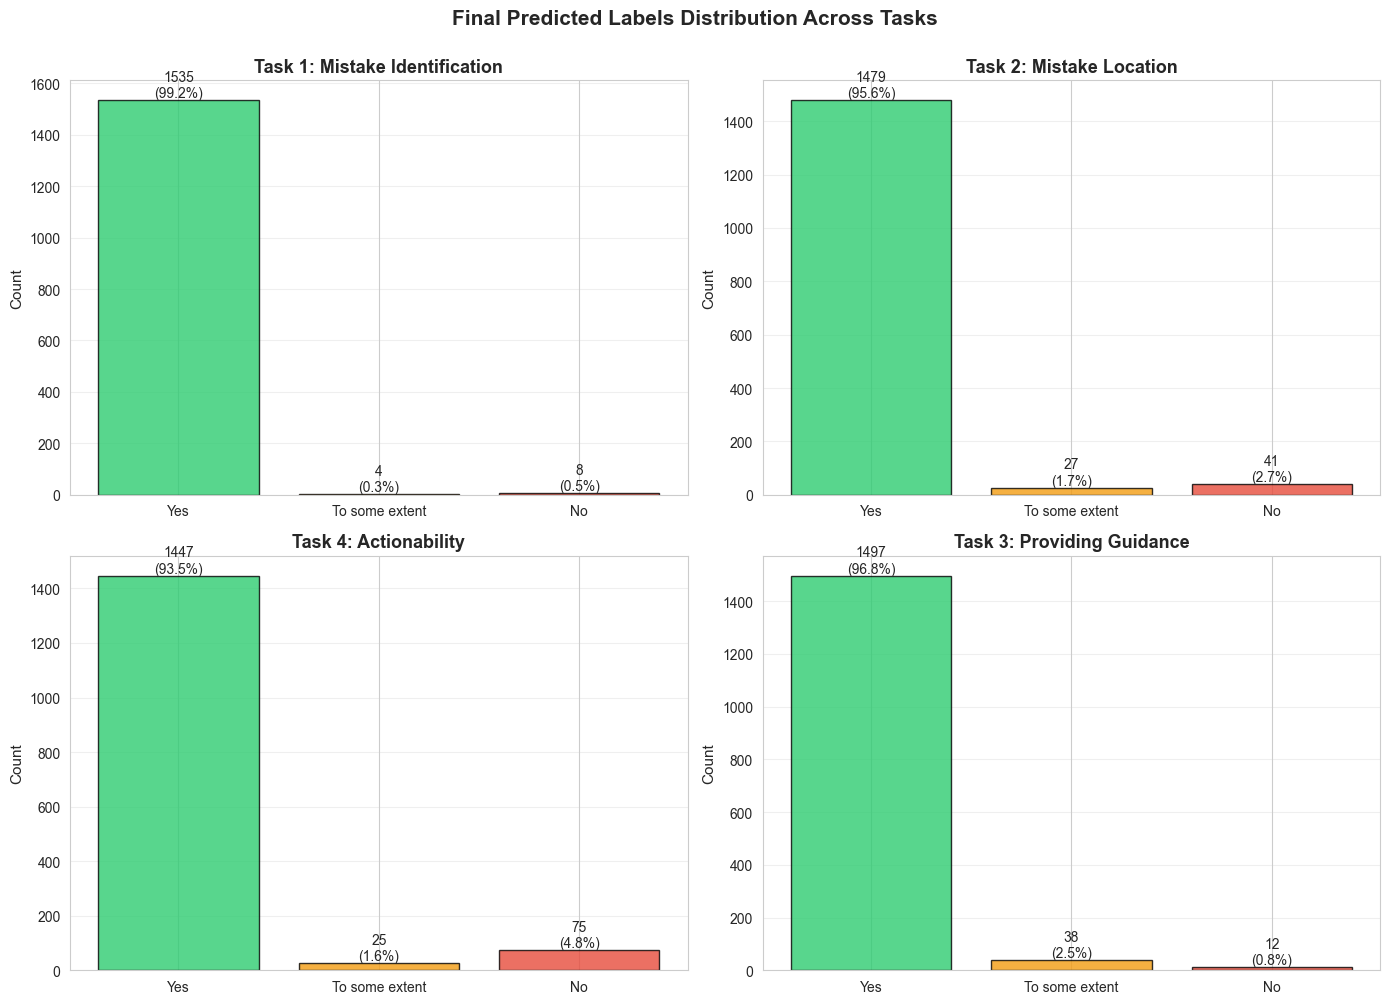

In [6]:
# Visualization: Label distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

task_names_short = ['Task 1: Mistake Identification', 'Task 2: Mistake Location', 'Task 4: Actionability', 'Task 3: Providing Guidance']
all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']

for idx, (task, short_name) in enumerate(zip(all_tasks, task_names_short)):
    if final_predictions[task]:
        label_counts = Counter(final_predictions[task])
        labels = ['Yes', 'To some extent', 'No']
        counts = [label_counts.get(label, 0) for label in labels]
        colors = ['#2ecc71', '#f39c12', '#e74c3c']
        
        bars = axes[idx].bar(labels, counts, color=colors, edgecolor='black', alpha=0.8)
        axes[idx].set_ylabel('Count', fontsize=11)
        axes[idx].set_title(short_name, fontsize=13, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add percentage labels
        total = sum(counts)
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{count}\n({count/total*100:.1f}%)',
                          ha='center', va='bottom', fontsize=10)

plt.suptitle('Final Predicted Labels Distribution Across Tasks', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 3. Label Evolution Across Iterations


In [7]:
# Track label changes across iterations
label_changes = {task: defaultdict(int) for task in bd_tasks}
label_changes['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(int)

for conv in data:
    iterations = conv['iterations']
    if len(iterations) > 1:
        for i in range(len(iterations) - 1):
            curr_iter = iterations[i]['predictions']
            next_iter = iterations[i + 1]['predictions']
            
            # BD predictions
            for task in bd_tasks:
                if task in curr_iter['bd_predictions'] and task in next_iter['bd_predictions']:
                    curr_label = curr_iter['bd_predictions'][task]['predicted_label']
                    next_label = next_iter['bd_predictions'][task]['predicted_label']
                    
                    if curr_label != next_label:
                        transition = f"{curr_label} → {next_label}"
                        label_changes[task][transition] += 1
            
            # IALab prediction
            if 'ialabuc_prediction' in curr_iter and 'ialabuc_prediction' in next_iter:
                curr_label = curr_iter['ialabuc_prediction']['predicted_label']
                next_label = next_iter['ialabuc_prediction']['predicted_label']
                
                if curr_label != next_label:
                    transition = f"{curr_label} → {next_label}"
                    label_changes['Providing Guidance (should provide the student with relevant and helpful guidance)'][transition] += 1

# Display label changes
print("=" * 60)
print("TOTAL LABEL CHANGES ACROSS ITERATIONS")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if label_changes[task]:
        total_changes = sum(label_changes[task].values())
        print(f"  Total label changes: {total_changes}")
        for transition, count in sorted(label_changes[task].items(), key=lambda x: x[1], reverse=True):
            print(f"    {transition}: {count} times")
    else:
        print("  No label changes observed")

TOTAL LABEL CHANGES ACROSS ITERATIONS

Mistake Identification (includes the relevant mistake identification):
  Total label changes: 333
    No → Yes: 243 times
    To some extent → Yes: 66 times
    Yes → No: 15 times
    No → To some extent: 4 times
    Yes → To some extent: 4 times
    To some extent → No: 1 times

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Total label changes: 527
    No → Yes: 377 times
    To some extent → Yes: 91 times
    Yes → No: 43 times
    No → To some extent: 7 times
    Yes → To some extent: 7 times
    To some extent → No: 2 times

Actionability (provides what the student should do next):
  Total label changes: 657
    No → Yes: 349 times
    To some extent → Yes: 173 times
    Yes → No: 64 times
    Yes → To some extent: 28 times
    No → To some extent: 24 times
    To some extent → No: 19 times

Providing Guidance (should provide the student with relevant and helpfu

In [8]:
# Track label changes across iterations (overall + by iteration step)
label_changes = {task: defaultdict(int) for task in bd_tasks}
label_changes['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(int)

label_changes_by_step = {task: defaultdict(lambda: defaultdict(int)) for task in bd_tasks}
label_changes_by_step['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(lambda: defaultdict(int))

for conv in data:
    iterations = conv['iterations']
    if len(iterations) > 1:
        for i in range(len(iterations) - 1):
            curr_iter = iterations[i]['predictions']
            next_iter = iterations[i + 1]['predictions']
            step_key = (i + 1, i + 2)

            # BD predictions
            for task in bd_tasks:
                if task in curr_iter['bd_predictions'] and task in next_iter['bd_predictions']:
                    curr_label = curr_iter['bd_predictions'][task]['predicted_label']
                    next_label = next_iter['bd_predictions'][task]['predicted_label']

                    if curr_label != next_label:
                        transition = f"{curr_label} → {next_label}"
                        label_changes[task][transition] += 1
                        label_changes_by_step[task][step_key][transition] += 1

            # IALab prediction
            if 'ialabuc_prediction' in curr_iter and 'ialabuc_prediction' in next_iter:
                curr_label = curr_iter['ialabuc_prediction']['predicted_label']
                next_label = next_iter['ialabuc_prediction']['predicted_label']

                if curr_label != next_label:
                    transition = f"{curr_label} → {next_label}"
                    guidance_task = 'Providing Guidance (should provide the student with relevant and helpful guidance)'
                    label_changes[guidance_task][transition] += 1
                    label_changes_by_step[guidance_task][step_key][transition] += 1

# Display label changes
print("=" * 60)
print("LABEL CHANGES ACROSS ITERATIONS")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if label_changes[task]:
        total_changes = sum(label_changes[task].values())
        print(f"  Total label changes: {total_changes}")
        print("  Changes by iteration step:")

        for step_key in sorted(label_changes_by_step[task].keys()):
            step_total = sum(label_changes_by_step[task][step_key].values())
            print(f"    Iteration {step_key[0]} → {step_key[1]}: {step_total} change(s)")
            for transition, count in sorted(label_changes_by_step[task][step_key].items(), key=lambda x: x[1], reverse=True):
                print(f"      {transition}: {count} times")

        print("  Overall transitions:")
        for transition, count in sorted(label_changes[task].items(), key=lambda x: x[1], reverse=True):
            print(f"    {transition}: {count} times")
    else:
        print("  No label changes observed")

LABEL CHANGES ACROSS ITERATIONS

Mistake Identification (includes the relevant mistake identification):
  Total label changes: 333
  Changes by iteration step:
    Iteration 1 → 2: 300 change(s)
      No → Yes: 223 times
      To some extent → Yes: 61 times
      Yes → No: 10 times
      Yes → To some extent: 3 times
      No → To some extent: 2 times
      To some extent → No: 1 times
    Iteration 2 → 3: 33 change(s)
      No → Yes: 20 times
      Yes → No: 5 times
      To some extent → Yes: 5 times
      No → To some extent: 2 times
      Yes → To some extent: 1 times
  Overall transitions:
    No → Yes: 243 times
    To some extent → Yes: 66 times
    Yes → No: 15 times
    No → To some extent: 4 times
    Yes → To some extent: 4 times
    To some extent → No: 1 times

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Total label changes: 527
  Changes by iteration step:
    Iteration 1 → 2: 454 change(

In [9]:
# Sankey diagrams for CHANGES ONLY with explicit iteration stages (1 -> 2 -> 3)
import plotly.graph_objects as go

# Define task display names
task_display_names = {
    'Mistake Identification (includes the relevant mistake identification)': 'Task 1: Mistake Identification',
    'Mistake Location (points to the mistake\'s location in the answer and outline what the error is to help the student remediate)': 'Task 2: Mistake Location',
    'Actionability (provides what the student should do next)': 'Task 4: Actionability',
    'Providing Guidance (should provide the student with relevant and helpful guidance)': 'Task 3: Providing Guidance'
}

label_options = ['Yes', 'To some extent', 'No']
all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']

for task in all_tasks:
    task_steps = label_changes_by_step[task]
    if not task_steps:
        continue

    task_short = task_display_names.get(task, task.split('(')[0].strip())

    # Build nodes for 3 columns: Iteration 1, Iteration 2, Iteration 3
    # Node labels contain only class names; iteration appears once as a column header.
    nodes = label_options + label_options + label_options

    sources = []
    targets = []
    values = []
    colors = []

    # Helper: style transition color
    def transition_color(source_label, target_label, alpha=0.45):
        if source_label == 'To some extent' and target_label == 'No':
            return f'rgba(231, 76, 60, {alpha})'    # red (to some extent -> no)
        if source_label == 'No' and target_label == 'To some extent':
            return f'rgba(243, 156, 18, {alpha})'   # orange (no -> to some extent)
        if source_label == 'No' and target_label == 'Yes':
            return f'rgba(46, 204, 113, {alpha})'   # green (strong improvement)
        if source_label == 'To some extent' and target_label == 'Yes':
            return f'rgba(46, 204, 113, {alpha})'   # green (improvement)
        if source_label == 'Yes' and target_label in ['To some extent', 'No']:
            return f'rgba(231, 76, 60, {alpha})'    # red (degradation)
        return f'rgba(52, 152, 219, {alpha})'       # lateral change

    # Iteration 1 -> Iteration 2 (changes only)
    for src_label in label_options:
        for tgt_label in label_options:
            if src_label == tgt_label:
                continue
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((1, 2), {}).get(transition, 0)
            if count > 0:
                sources.append(label_options.index(src_label))
                targets.append(3 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.50))

    # Iteration 2 -> Iteration 3 (changes only)
    for src_label in label_options:
        for tgt_label in label_options:
            if src_label == tgt_label:
                continue
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((2, 3), {}).get(transition, 0)
            if count > 0:
                sources.append(3 + label_options.index(src_label))
                targets.append(6 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.35))

    if not values:
        continue

    step12_total = sum(task_steps.get((1, 2), {}).values())
    step23_total = sum(task_steps.get((2, 3), {}).values())

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=20,
            thickness=24,
            line=dict(color='black', width=0.5),
            label=nodes,
            color=['#2ecc71', '#f39c12', '#e74c3c'] * 3
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            hovertemplate='%{source.label} → %{target.label}<br>Count: %{value}<extra></extra>'
        )
    )])

    fig.update_layout(
        title=(
            f"{task_short}<br>"
            f"<sub>Iteration 1→2: {step12_total} changes | Iteration 2→3: {step23_total} changes</sub>"
        ),
        annotations=[
            dict(x=0.0, y=-0.09, xref='paper', yref='paper', text='Iteration 1', showarrow=False, font=dict(size=18)),
            dict(x=0.50, y=-0.09, xref='paper', yref='paper', text='Iteration 2', showarrow=False, font=dict(size=18)),
            dict(x=1, y=-0.09, xref='paper', yref='paper', text='Iteration 3', showarrow=False, font=dict(size=18)),
        ],
        font=dict(size=22),
        height=450,
        width=1000,
        showlegend=False,
        margin=dict(l=40, r=40, t=120, b=40)
    )

    fig.show()

In [10]:
# Track ALL label transitions across iterations (including no-change transitions)
all_label_transitions = {task: defaultdict(int) for task in bd_tasks}
all_label_transitions['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(int)

all_label_transitions_by_step = {task: defaultdict(lambda: defaultdict(int)) for task in bd_tasks}
all_label_transitions_by_step['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(lambda: defaultdict(int))

for conv in data:
    iterations = conv['iterations']
    if len(iterations) > 1:
        for i in range(len(iterations) - 1):
            curr_iter = iterations[i]['predictions']
            next_iter = iterations[i + 1]['predictions']
            step_key = (i + 1, i + 2)

            # BD predictions (count all transitions, even when label does not change)
            for task in bd_tasks:
                if task in curr_iter['bd_predictions'] and task in next_iter['bd_predictions']:
                    curr_label = curr_iter['bd_predictions'][task]['predicted_label']
                    next_label = next_iter['bd_predictions'][task]['predicted_label']
                    transition = f"{curr_label} → {next_label}"
                    all_label_transitions[task][transition] += 1
                    all_label_transitions_by_step[task][step_key][transition] += 1

            # IALab prediction (count all transitions, even when label does not change)
            if 'ialabuc_prediction' in curr_iter and 'ialabuc_prediction' in next_iter:
                curr_label = curr_iter['ialabuc_prediction']['predicted_label']
                next_label = next_iter['ialabuc_prediction']['predicted_label']
                transition = f"{curr_label} → {next_label}"
                guidance_task = 'Providing Guidance (should provide the student with relevant and helpful guidance)'
                all_label_transitions[guidance_task][transition] += 1
                all_label_transitions_by_step[guidance_task][step_key][transition] += 1

# Display all transitions
print("=" * 60)
print("ALL LABEL TRANSITIONS ACROSS ITERATIONS (INCLUDING NO CHANGE)")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if all_label_transitions[task]:
        total_transitions = sum(all_label_transitions[task].values())
        print(f"  Total transitions: {total_transitions}")
        print("  Transitions by iteration step:")

        for step_key in sorted(all_label_transitions_by_step[task].keys()):
            step_total = sum(all_label_transitions_by_step[task][step_key].values())
            print(f"    Iteration {step_key[0]} → {step_key[1]}: {step_total} transition(s)")
            for transition, count in sorted(all_label_transitions_by_step[task][step_key].items(), key=lambda x: x[1], reverse=True):
                print(f"      {transition}: {count} times")

        print("  Overall transitions:")
        for transition, count in sorted(all_label_transitions[task].items(), key=lambda x: x[1], reverse=True):
            print(f"    {transition}: {count} times")
    else:
        print("  No transitions observed")

ALL LABEL TRANSITIONS ACROSS ITERATIONS (INCLUDING NO CHANGE)

Mistake Identification (includes the relevant mistake identification):
  Total transitions: 1344
  Transitions by iteration step:
    Iteration 1 → 2: 1010 transition(s)
      Yes → Yes: 695 times
      No → Yes: 223 times
      To some extent → Yes: 61 times
      No → No: 14 times
      Yes → No: 10 times
      Yes → To some extent: 3 times
      No → To some extent: 2 times
      To some extent → No: 1 times
      To some extent → To some extent: 1 times
    Iteration 2 → 3: 334 transition(s)
      Yes → Yes: 297 times
      No → Yes: 20 times
      Yes → No: 5 times
      To some extent → Yes: 5 times
      No → No: 3 times
      No → To some extent: 2 times
      To some extent → To some extent: 1 times
      Yes → To some extent: 1 times
  Overall transitions:
    Yes → Yes: 992 times
    No → Yes: 243 times
    To some extent → Yes: 66 times
    No → No: 17 times
    Yes → No: 15 times
    No → To some extent: 4 time

In [11]:
# Sankey diagrams for ALL transitions with explicit iteration stages (1 -> 2 -> 3)
import plotly.graph_objects as go

# Define task display names
task_display_names = {
    'Mistake Identification (includes the relevant mistake identification)': 'Task 1: Mistake Identification',
    'Mistake Location (points to the mistake\'s location in the answer and outline what the error is to help the student remediate)': 'Task 2: Mistake Location',
    'Actionability (provides what the student should do next)': 'Task 4: Actionability',
    'Providing Guidance (should provide the student with relevant and helpful guidance)': 'Task 3: Providing Guidance'
}

label_options = ['Yes', 'To some extent', 'No']
all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']

for task in all_tasks:
    task_steps = all_label_transitions_by_step[task]
    if not task_steps:
        continue

    task_short = task_display_names.get(task, task.split('(')[0].strip())

    # Build nodes for 3 columns: Iteration 1, Iteration 2, Iteration 3
    nodes = (
        [f"{label}<br>(Iteration 1)" for label in label_options] +
        [f"{label}<br>(Iteration 2)" for label in label_options] +
        [f"{label}<br>(Iteration 3)" for label in label_options]
    )

    sources = []
    targets = []
    values = []
    colors = []

    # Helper: style transition color
    def transition_color(source_label, target_label, alpha=0.45):
        if source_label == target_label:
            return f'rgba(120, 120, 120, {alpha})'  # no-change
        if source_label == 'No' and target_label in ['To some extent', 'Yes']:
            return f'rgba(46, 204, 113, {alpha})'   # improvement
        if source_label == 'To some extent' and target_label == 'Yes':
            return f'rgba(46, 204, 113, {alpha})'   # improvement
        if source_label == 'Yes' and target_label in ['To some extent', 'No']:
            return f'rgba(231, 76, 60, {alpha})'    # degradation
        return f'rgba(52, 152, 219, {alpha})'       # lateral mix

    # Iteration 1 -> Iteration 2
    for src_label in label_options:
        for tgt_label in label_options:
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((1, 2), {}).get(transition, 0)
            if count > 0:
                sources.append(label_options.index(src_label))
                targets.append(3 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.50))

    # Iteration 2 -> Iteration 3
    for src_label in label_options:
        for tgt_label in label_options:
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((2, 3), {}).get(transition, 0)
            if count > 0:
                sources.append(3 + label_options.index(src_label))
                targets.append(6 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.35))

    if not values:
        continue

    step12_total = sum(task_steps.get((1, 2), {}).values())
    step23_total = sum(task_steps.get((2, 3), {}).values())

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=20,
            thickness=24,
            line=dict(color='black', width=0.5),
            label=nodes,
            color=['#2ecc71', '#f39c12', '#e74c3c'] * 3
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            hovertemplate='%{source.label} → %{target.label}<br>Count: %{value}<extra></extra>'
        )
    )])

    fig.update_layout(
        title=(
            f"{task_short}<br>"
            f"<sub>Iteration 1→2 transitions: {step12_total} | Iteration 2→3 transitions: {step23_total}</sub>"
        ),
        font=dict(size=11),
        height=600,
        width=1050,
        showlegend=False,
        margin=dict(l=40, r=40, t=95, b=40)
    )

    fig.show()

## 4. Probability Analysis


In [10]:
# Analyze probability scores for final predictions
prob_data = {task: {'Yes': [], 'To some extent': [], 'No': []} for task in bd_tasks}
prob_data['Providing Guidance (should provide the student with relevant and helpful guidance)'] = {'Yes': [], 'To some extent': [], 'No': []}

for conv in data:
    final_pred = conv['predictions']
    
    # BD predictions
    for task in bd_tasks:
        if task in final_pred['bd_predictions']:
            probs = final_pred['bd_predictions'][task]['probabilities']
            for label in ['Yes', 'To some extent', 'No']:
                if label in probs:
                    prob_data[task][label].append(probs[label])
    
    # IALab prediction
    if 'ialabuc_prediction' in final_pred:
        probs = final_pred['ialabuc_prediction']['class_probabilities']
        for label in ['Yes', 'To some extent', 'No']:
            if label in probs:
                prob_data['Providing Guidance (should provide the student with relevant and helpful guidance)'][label].append(probs[label])

# Calculate statistics
print("=" * 60)
print("PROBABILITY STATISTICS (FINAL PREDICTIONS)")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    for label in ['Yes', 'To some extent', 'No']:
        if prob_data[task][label]:
            probs = prob_data[task][label]
            print(f"  {label}:")
            print(f"    Mean: {np.mean(probs):.4f}")
            print(f"    Median: {np.median(probs):.4f}")
            print(f"    Std: {np.std(probs):.4f}")

PROBABILITY STATISTICS (FINAL PREDICTIONS)

Mistake Identification (includes the relevant mistake identification):
  Yes:
    Mean: 0.9578
    Median: 0.9722
    Std: 0.0888
  To some extent:
    Mean: 0.0304
    Median: 0.0233
    Std: 0.0471
  No:
    Mean: 0.0118
    Median: 0.0043
    Std: 0.0705

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Yes:
    Mean: 0.6823
    Median: 0.7163
    Std: 0.1374
  To some extent:
    Mean: 0.1314
    Median: 0.0965
    Std: 0.0999
  No:
    Mean: 0.1864
    Median: 0.1497
    Std: 0.1187

Actionability (provides what the student should do next):
  Yes:
    Mean: 0.9097
    Median: 0.9892
    Std: 0.2394
  To some extent:
    Mean: 0.0370
    Median: 0.0074
    Std: 0.1294
  No:
    Mean: 0.0533
    Median: 0.0028
    Std: 0.2092

Providing Guidance (should provide the student with relevant and helpful guidance):
  Yes:
    Mean: 0.7909
    Median: 0.8838
    Std: 

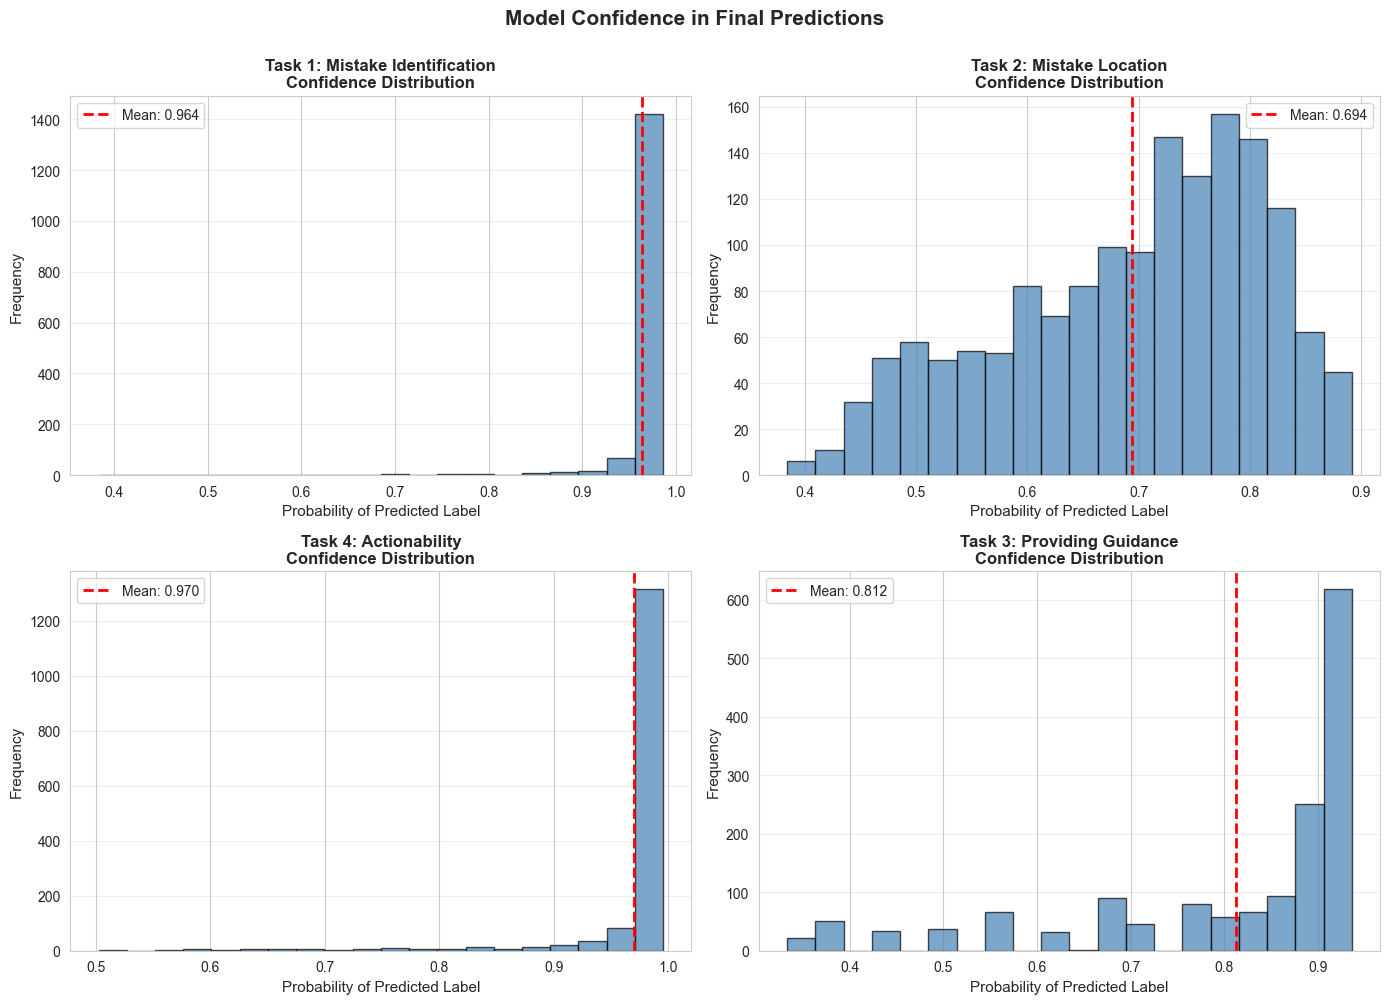

In [12]:
# Visualization: Probability distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']
task_names_short = ['Task 1: Mistake Identification', 'Task 2: Mistake Location', 'Task 4: Actionability', 'Task 3: Providing Guidance']

for idx, (task, short_name) in enumerate(zip(all_tasks, task_names_short)):
    # Collect probabilities for the predicted label
    predicted_probs = []
    for conv in data:
        final_pred = conv['predictions']
        
        if task == 'Providing Guidance (should provide the student with relevant and helpful guidance)':
            if 'ialabuc_prediction' in final_pred:
                pred_label = final_pred['ialabuc_prediction']['predicted_label']
                prob = final_pred['ialabuc_prediction']['class_probabilities'][pred_label]
                predicted_probs.append(prob)
        else:
            if task in final_pred['bd_predictions']:
                pred_label = final_pred['bd_predictions'][task]['predicted_label']
                prob = final_pred['bd_predictions'][task]['probabilities'][pred_label]
                predicted_probs.append(prob)
    
    if predicted_probs:
        axes[idx].hist(predicted_probs, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].axvline(np.mean(predicted_probs), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {np.mean(predicted_probs):.3f}')
        axes[idx].set_xlabel('Probability of Predicted Label', fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(f'{short_name}\nConfidence Distribution', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Model Confidence in Final Predictions', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

\*As the test set model labels are not available, the model comparison is not done


## 5. Summary Report


In [14]:
# Generate comprehensive summary
print("=" * 80)
print(" " * 20 + "REFINEMENT PROCESS SUMMARY REPORT")
print("=" * 80)

print(f"\n{'Dataset:':<30} MRBench v3 DevSet Refinements")
print(f"{'Total Conversations:':<30} {len(data)}")

print(f"\n{'ITERATION METRICS':-^80}")
print(f"{'Average Iterations:':<30} {np.mean(iteration_counts):.2f}")
print(f"{'Median Iterations:':<30} {np.median(iteration_counts):.0f}")
print(f"{'Iteration Range:':<30} {np.min(iteration_counts)} - {np.max(iteration_counts)}")

print(f"\n{'COMPLETION METRICS':-^80}")
completed = sum(completed_status)
print(f"{'Completed Refinements:':<30} {completed} ({completed/len(data)*100:.1f}%)")
print(f"{'Incomplete Refinements:':<30} {len(data)-completed} ({(len(data)-completed)/len(data)*100:.1f}%)")

print(f"\n{'LABEL DISTRIBUTION (FINAL)':-^80}")
for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    task_name = task.split('(')[0].strip() if '(' in task else task
    if final_predictions[task]:
        yes_count = sum(1 for l in final_predictions[task] if l == 'Yes')
        print(f"{task_name:<30} Yes: {yes_count/len(final_predictions[task])*100:.1f}%")

print(f"\n{'MODEL PERFORMANCE':-^80}")
for _, row in model_df.iterrows():
    print(f"{row['Model']:<15} | Avg Iter: {row['Avg Iterations']:.2f} | Completion: {row['Completion Rate (%)']:.1f}%")

print("\n" + "=" * 80)

                    REFINEMENT PROCESS SUMMARY REPORT

Dataset:                       MRBench v3 DevSet Refinements
Total Conversations:           1547

-------------------------------ITERATION METRICS--------------------------------
Average Iterations:            1.87
Median Iterations:             2
Iteration Range:               1 - 3

-------------------------------COMPLETION METRICS-------------------------------
Completed Refinements:         1369 (88.5%)
Incomplete Refinements:        178 (11.5%)

---------------------------LABEL DISTRIBUTION (FINAL)---------------------------
Mistake Identification         Yes: 99.2%
Mistake Location               Yes: 95.6%
Actionability                  Yes: 93.5%
Providing Guidance             Yes: 96.8%

-------------------------------MODEL PERFORMANCE--------------------------------
Tutor_1         | Avg Iter: 1.86 | Completion: 88.5%
Tutor_2         | Avg Iter: 1.85 | Completion: 87.4%
Tutor_3         | Avg Iter: 1.96 | Completion: 88.5%
